# Extended Data Figure 11

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

In [15]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':         pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':         pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0':     {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC':     {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':      {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':      {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                       'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    # FSR screens — d15 cols are 'd15-1','d15-2','d15-3'
    'ABE_EPO_T0_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_T0_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_EPO_BC_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_BC_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_BC_T0_FSR':  {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_BC_T0_FSR':  {'bm':    ['bm2','bm3','bm4','bm5'],
                       'spleen':['spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')


Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides
  ABE_EPO_T0_FSR: 376 guides
  CBE_EPO_T0_FSR: 1257 guides
  ABE_EPO_BC_FSR: 376 guides
  CBE_EPO_BC_FSR: 1257 guides
  ABE_BC_T0_FSR: 376 guides
  CBE_BC_T0_FSR: 1257 guides


In [16]:
# load library

LIB = pd.read_csv(BASE + 'MBESv2_CORRECTED.csv')
LIB_FOCUSED = pd.read_csv(BASE + 'MBESv2_focused.csv')

ABE = LIB[LIB['Editor'] == 'ABE'].reset_index(drop=True)
ABE_FOCUSED = LIB_FOCUSED[LIB_FOCUSED['Editor'] == 'ABE'].reset_index(drop=True)

In [17]:
ABE['classification'].value_counts()

classification
targeting guide           1034
safe-targeting control      26
non-targeting control       10
Name: count, dtype: int64

In [18]:
n_controls = len(ABE[ABE['classification'].isin(['non-targeting control', 'safe-targeting control'])])
n_all= len(ABE)
print(f'Library: {n_controls/n_all*100:.1f}% (n= {n_controls}/{n_all}) non- and safe-targeting guides')

n_controls = len(ABE_FOCUSED[ABE_FOCUSED['classification'].isin(['non-targeting control', 'safe-targeting control'])])
n_all= len(ABE_FOCUSED)
print(f'Library Focused: {n_controls/n_all*100:.1f}% (n= {n_controls}/{n_all}) non- and safe-targeting guides')

Library: 3.4% (n= 36/1070) non- and safe-targeting guides
Library Focused: 54.8% (n= 206/376) non- and safe-targeting guides


## 11a

Selection of ABE focused library hits.

10% editing, only targeting guides; FDR .1, |LFC|>1

In [ ]:
def volcano_plot(df, screen_name, conditions,
                 effect='median', fdr_method='fishers',
                 fdr_cutoff=0.1, lfc_cutoff=1.0,
                 is_og=False, show_controls=True, edit_cutoff=20):
    min_sensor  = 10 if is_og else 100

    n = len(conditions)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]

    _cmap = plt.cm.Blues

    input_ok = df['Input_median'] >= 2 if 'Input_median' in df.columns else pd.Series(True, index=df.index)

    for k, cond in enumerate(conditions):
        lfc_col   = f'LFC_{effect}_{cond}'
        fdr_col   = f'FDR_{cond}_{fdr_method}'
        reads_col = f'sensor_reads_{cond}'
        edit_col  = f'target_base_edit_perc_{cond}'
        if lfc_col not in df.columns or fdr_col not in df.columns:
            continue
        ax = axes[k]

        if reads_col in df.columns and edit_col in df.columns:
            guide_ok = input_ok & (df[reads_col] >= min_sensor) & (df[edit_col] >= edit_cutoff)
        else:
            guide_ok = input_ok

        targ  = df[(df['classification'] == 'targeting guide') & guide_ok].copy()
        trunc = df[(df['classification'] == 'essential truncation guide') & guide_ok].copy()
        ntc   = df[df['classification'] == 'non-targeting control'].copy()
        stc   = df[df['classification'] == 'safe-targeting control'].copy()

        # Targeting guides — blue FDR gradient
        if len(targ):
            neg_log_fdr = -np.log10(targ[fdr_col].clip(lower=1e-300))
            vmax = max(neg_log_fdr.max(), -np.log10(fdr_cutoff) * 2)
            norm = plt.Normalize(vmin=0, vmax=vmax)
            colors_targ = _cmap(norm(neg_log_fdr))
            ax.scatter(targ[lfc_col], neg_log_fdr,
                       c=colors_targ, s=20, alpha=0.6,
                       linewidths=0, edgecolors='none')

        if show_controls:
            # Neutral controls — red (no editing filter)
            for ctrl in [ntc, stc]:
                if len(ctrl):
                    yvals = -np.log10(ctrl[fdr_col].clip(lower=1e-300))
                    ax.scatter(ctrl[lfc_col], yvals,
                               c='#e41a1c', s=30, alpha=0.7,
                               linewidths=0, edgecolors='none', zorder=3)

            # Truncation controls — yellow (same editing filter as targeting guides)
            if len(trunc):
                yvals = -np.log10(trunc[fdr_col].clip(lower=1e-300))
                ax.scatter(trunc[lfc_col], yvals,
                           c='#ffcc00', s=30, alpha=0.8,
                           linewidths=0, edgecolors='none', zorder=3)

        ax.axhline(-np.log10(fdr_cutoff), color='black', linestyle='--', linewidth=0.8)
        ax.axvline( lfc_cutoff, color='grey', linestyle=':', linewidth=0.8)
        ax.axvline(-lfc_cutoff, color='grey', linestyle=':', linewidth=0.8)
        n_hits = int(((targ[fdr_col] < fdr_cutoff) & (targ[lfc_col].abs() > lfc_cutoff)).sum()) if len(targ) else 0
        cond_label = {'bm':'Bone Marrow','spleen':'Spleen','men':'Meninges','d15':'D15'}.get(cond, cond)
        ax.set_title(f'{cond_label}  (n={n_hits} hits)', fontsize=16)
        ax.set_xlabel(f'{effect.replace("_"," ").title()} LFC', fontsize=16)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=16, direction='out', length=6, width=1)
        if k == 0:
            ax.set_ylabel(f'-log10(FDR {fdr_method})', fontsize=16)

    min_s_label = f'sensor>={min_sensor}, edit>={edit_cutoff}%, input>=2'
    fig.suptitle(f'{screen_name}  |  {effect}  |  {fdr_method}  |  {min_s_label}', fontsize=16, y=1.01)
    fig.tight_layout()
    plt.show()


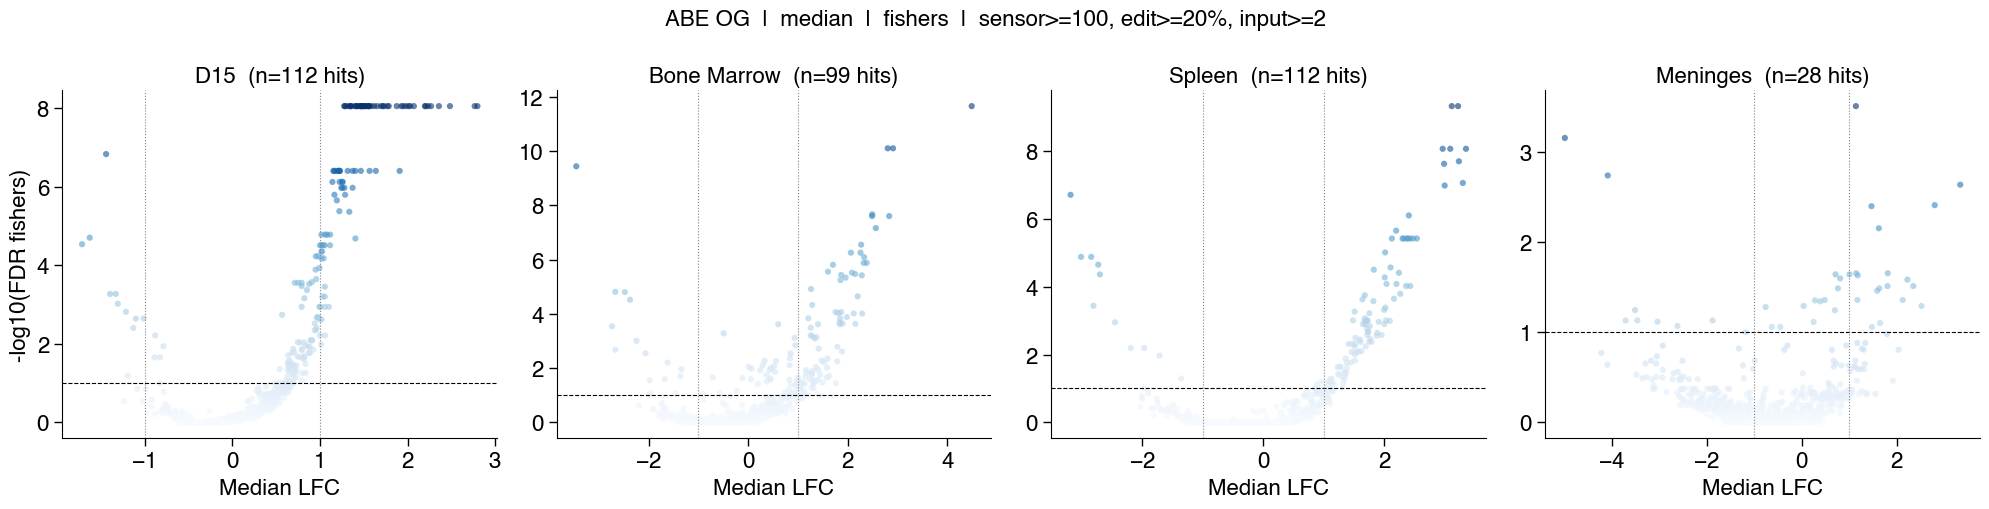

In [ ]:
volcano_plot(dfs['ABE_OG'], 'ABE OG', conds_og, effect='median', fdr_method='fishers', show_controls=False, )